# Outline


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('zameen_eda_cleaned.csv',index_col=0)

In [5]:
df.shape

(6353, 38)

In [6]:
df.columns

Index(['Building', 'Main Location', 'Type', 'Price(Cr)', 'Bath(s)',
       'Area(Marla)', 'Bedroom(s)', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Floor in Building', 'Bedrooms',
       'Bathrooms', 'Servant Quarters', 'Kitchens', 'Store Rooms',
       'Swimming Pool', 'Sauna', 'Jacuzzi', 'Security Staff',
       'Maintenance Staff', 'Facilities for Disabled',
       'Laundry or Dry Cleaning Facility', 'Communal/Shared Kitchen',
       'Storey Unit'],
      dtype='str')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 6353 entries, 0 to 6482
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Building                            6353 non-null   str    
 1   Main Location                       6353 non-null   str    
 2   Type                                6353 non-null   str    
 3   Price(Cr)                           6353 non-null   float64
 4   Bath(s)                             6239 non-null   float64
 5   Area(Marla)                         6353 non-null   float64
 6   Bedroom(s)                          6229 non-null   float64
 7   Description                         6353 non-null   str    
 8   Amenities: Main Features            5904 non-null   str    
 9   Amenities: Rooms                    5738 non-null   str    
 10  Amenities: Healthcare Recreational  4966 non-null   str    
 11  Amenities: Other Facilities         5554 non-null   str    

## Type vs Price

<Axes: xlabel='Type', ylabel='Price(Cr)'>

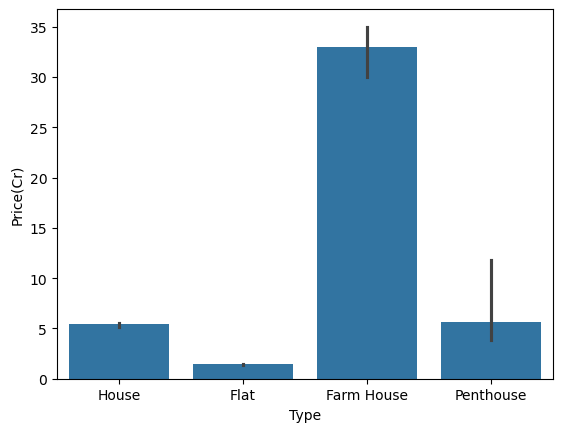

In [9]:
sns.barplot(data=df,x='Type',y='Price(Cr)',estimator=np.median)

<Axes: xlabel='Type', ylabel='Price(Cr)'>

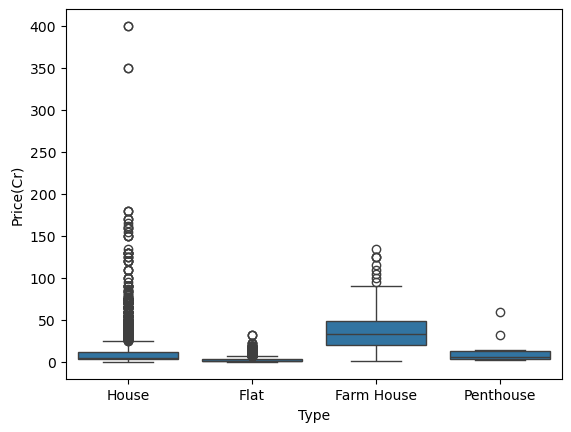

In [10]:
sns.boxplot(data=df,x='Type',y='Price(Cr)')

In [11]:
df[df['Type']=='Penthouse'].shape[0]

14

In [12]:
df[df['Type']=='Penthouse']['Price(Cr)'].mean()

np.float64(12.028571428571428)

### Observations
- The House category has a higher range having plenty of outliers.
- Flats has lower Price values as compared to others.
- Penthouse has lower median because of less number of rows.

## Area vs Price

<Axes: xlabel='Area(Marla)', ylabel='Price(Cr)'>

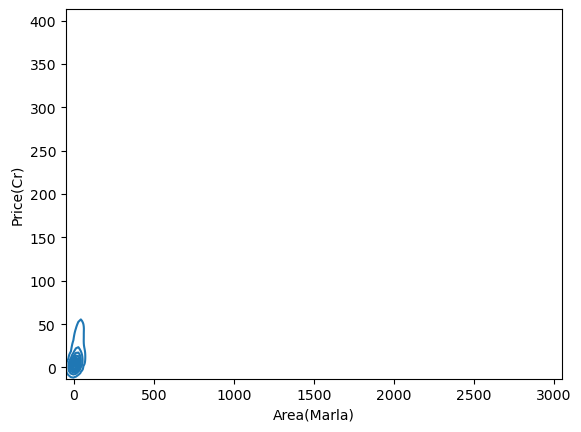

In [13]:
sns.kdeplot(data=df,x='Area(Marla)',y='Price(Cr)')

<Axes: xlabel='Area(Marla)', ylabel='Price(Cr)'>

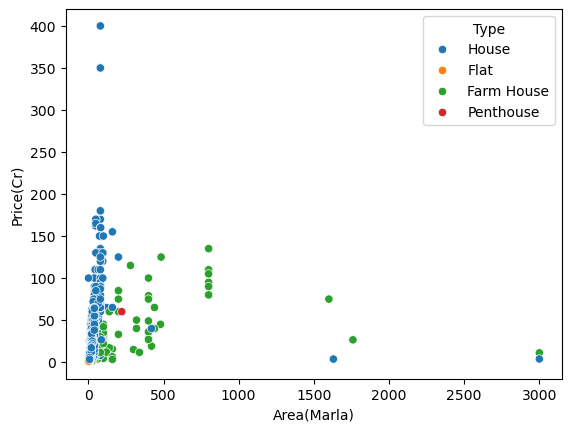

In [14]:
sns.scatterplot(data=df,x='Area(Marla)',y='Price(Cr)',hue='Type')

#### Finding Multivariate outliers using Isolation Forest and Local Outlier Factor and Visualizing it 

In [15]:
# Isolation Forest
from sklearn.ensemble import IsolationForest

clf = IsolationForest(max_samples=100,contamination='auto')
clf.fit(df[['Price(Cr)','Area(Marla)']])
y_pred = clf.predict(df[['Price(Cr)','Area(Marla)']])

In [16]:
y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(6353,))

In [17]:
pd.Series(y_pred).unique()

array([ 1, -1])

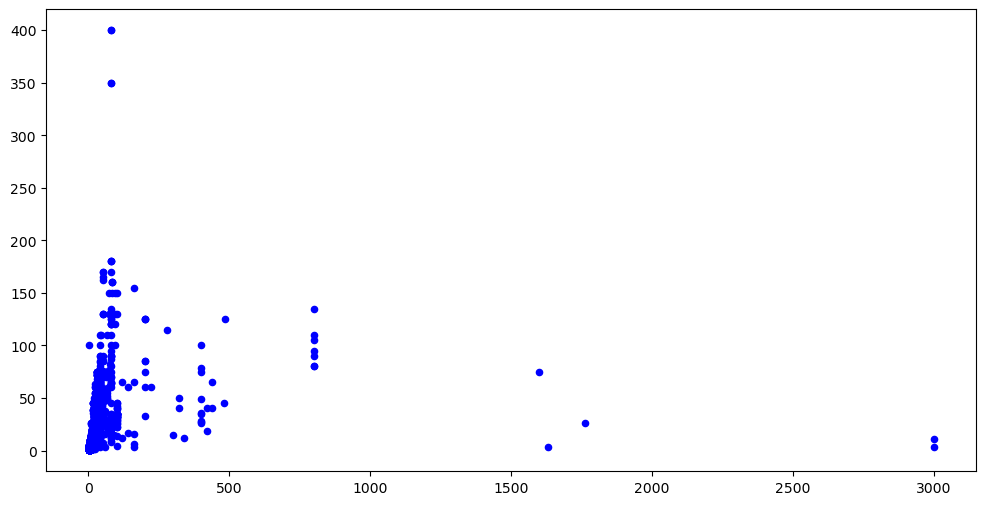

In [18]:
plt.figure(figsize=(12,6))
plt.scatter(x=df['Area(Marla)'],y=df['Price(Cr)'],s=20,color='b')

is_outlier = y_pred == -1
#plt.scatter()

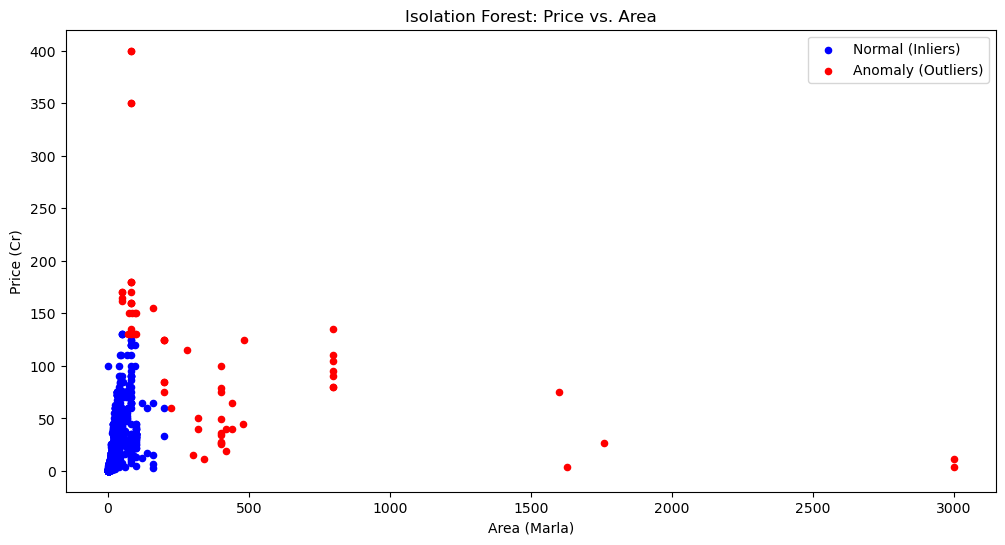

In [19]:
clf = IsolationForest(max_samples=500,contamination=0.01)
clf.fit(df[['Price(Cr)','Area(Marla)']])
y_pred = clf.predict(df[['Price(Cr)','Area(Marla)']])

# Creating the boolean mask (-1 means outlier, 1 means inlier)
is_outlier = y_pred == -1

plt.figure(figsize=(12, 6))

plt.scatter(x=df.loc[~is_outlier, 'Area(Marla)'], y=df.loc[~is_outlier, 'Price(Cr)'], 
            s=20, color='blue', label='Normal (Inliers)')

plt.scatter(x=df.loc[is_outlier, 'Area(Marla)'], y=df.loc[is_outlier, 'Price(Cr)'], 
            s=20, color='red', label='Anomaly (Outliers)')


plt.title('Isolation Forest: Price vs. Area')
plt.xlabel('Area (Marla)')
plt.ylabel('Price (Cr)')
plt.legend()
plt.show()

In [20]:
# Returns outliers rows
df.loc[is_outlier].shape

(64, 38)

C:\Users\Wajih\anaconda3\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


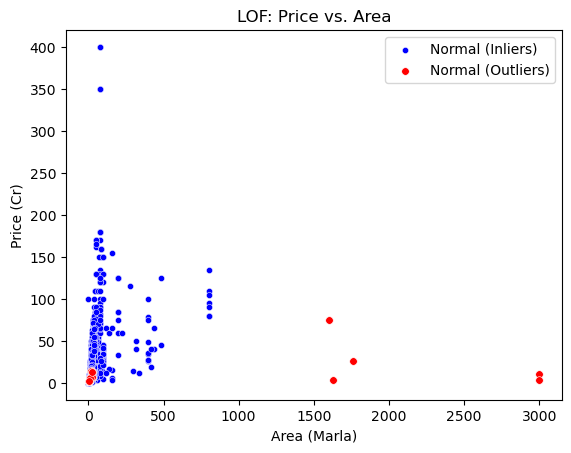

In [21]:
# Local Outlier Factor

from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=50,n_jobs=-1,contamination=0.01)
y_pred = lof.fit_predict(df[['Price(Cr)','Area(Marla)']])

is_outlier_lof = y_pred == -1

sns.scatterplot(data=df.loc[~is_outlier_lof],x='Area(Marla)',y='Price(Cr)',
               s=20,color='b', label='Normal (Inliers)')

sns.scatterplot(data=df.loc[is_outlier_lof],x='Area(Marla)',y='Price(Cr)',
               s=30,color='r',  label='Normal (Outliers)')

plt.title('LOF: Price vs. Area')
plt.xlabel('Area (Marla)')
plt.ylabel('Price (Cr)')
plt.legend()
plt.show()

*Removing the Outliers and visualizing the effect*

Text(0.5, 1.0, 'LOF')

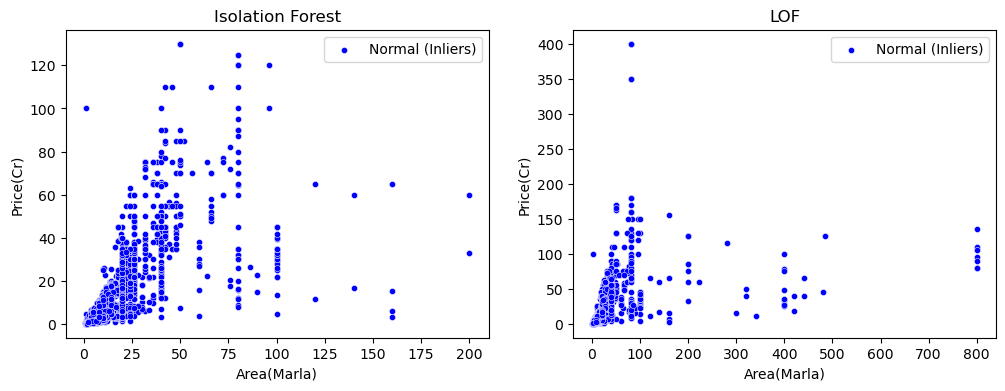

In [22]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(12,4))

sns.scatterplot(x=df.loc[~is_outlier, 'Area(Marla)'], y=df.loc[~is_outlier, 'Price(Cr)'], 
            s=20, color='blue', label='Normal (Inliers)',ax=ax[0])
ax[0].set_title("Isolation Forest")


sns.scatterplot(x=df.loc[~is_outlier_lof, 'Area(Marla)'], y=df.loc[~is_outlier_lof, 'Price(Cr)'], 
            s=20, color='blue', label='Normal (Inliers)',ax=ax[1])
ax[1].set_title("LOF")

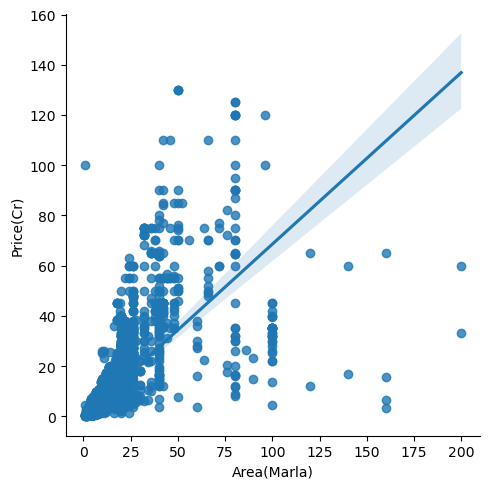

In [23]:
sns.lmplot(data=df.loc[~is_outlier],x='Area(Marla)',y='Price(Cr)')

### Obervations 
- Isolation Forest is proving better results since the data is not dense.
- The relations ship between Area and Price is kind of Linear (excluding Outliers)

## Type vs Area(Marla)

<Axes: xlabel='Type', ylabel='Area(Marla)'>

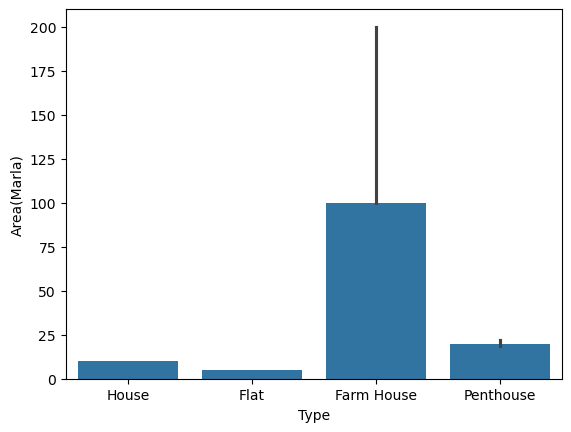

In [24]:
sns.barplot(x=df['Type'],y=df['Area(Marla)'],estimator=np.median)

<Axes: xlabel='Type', ylabel='Area(Marla)'>

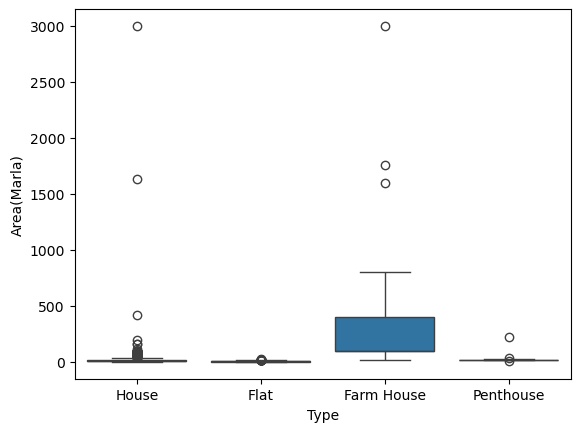

In [25]:
sns.boxplot(data =df,x='Type',y='Area(Marla)')

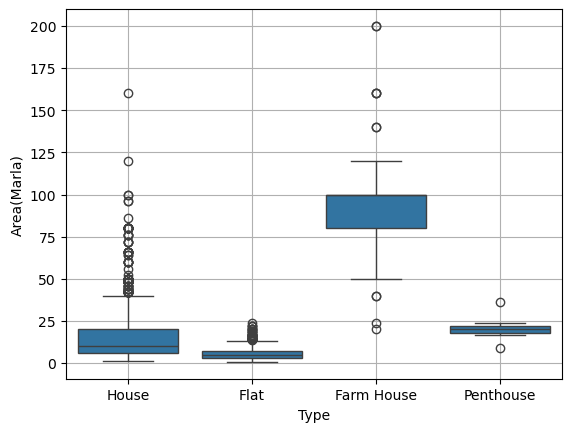

In [26]:
sns.boxplot(data =df.loc[~is_outlier] ,x='Type',y='Area(Marla)')
plt.grid();

## Bath(s) & Bedroom(s) vs Price

<Axes: xlabel='Bath(s)', ylabel='Price(Cr)'>

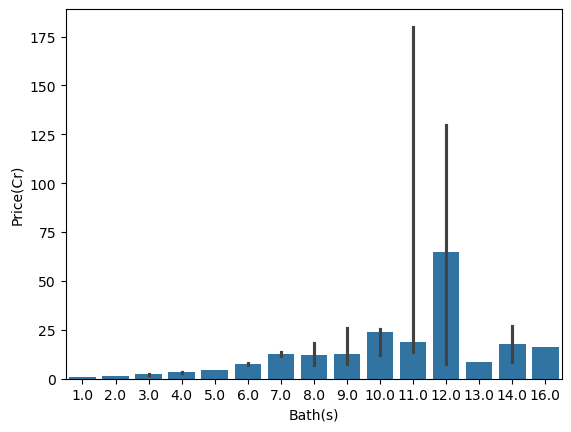

In [27]:
sns.barplot(x=df['Bath(s)'],y=df['Price(Cr)'],estimator=np.median)

<Axes: xlabel='Bedroom(s)', ylabel='Price(Cr)'>

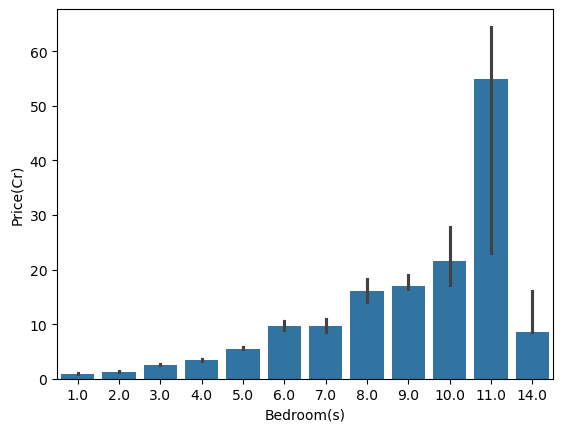

In [28]:
sns.barplot(x=df['Bedroom(s)'],y=df['Price(Cr)'],estimator=np.median)

### Observations 
- As the Bedrooms and Bathrooms increase so does the price.
- The last value of Bedrooms and Bathsrooms suggest an Outliers behaviour.

## Type vs Bedroom(s) & Bath(s)

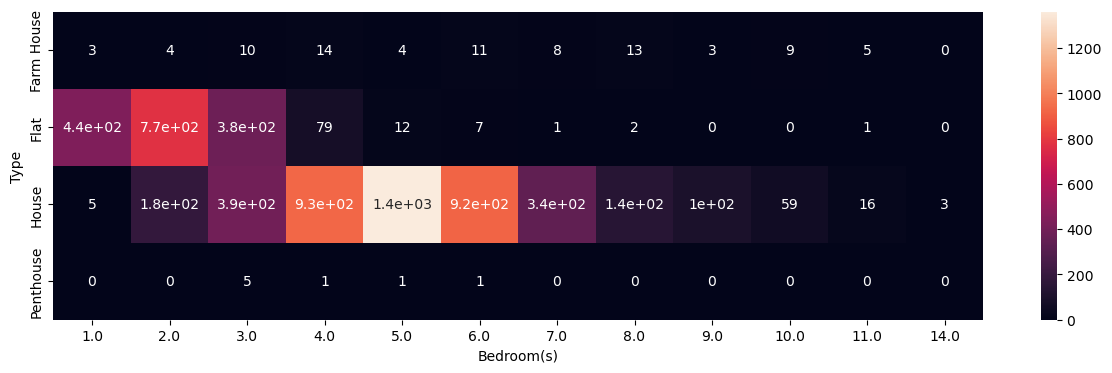

In [29]:
plt.figure(figsize=(15,4))
sns.heatmap(pd.crosstab(df['Type'],columns=df['Bedroom(s)']),annot=True);

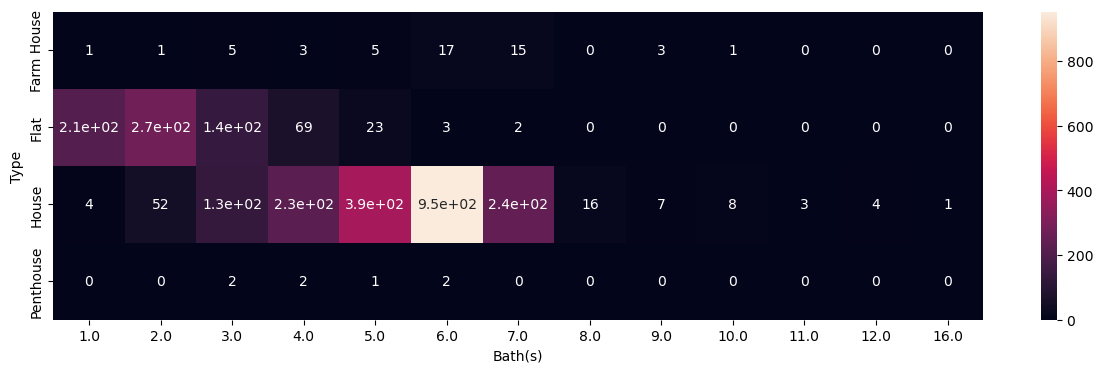

In [28]:
plt.figure(figsize=(15,4))
sns.heatmap(pd.crosstab(df['Type'],columns=df['Bath(s)']),annot=True);

## Observations
- **Bedrooms in Flats:** Common range is 1 - 3/4
- **Bedrooms in Houses:** Common range is 3 - 7
<br>

- **Bathrooms in Flats:** Common range is  1 -3
- **Bathrooms in Houses:** Common range is 2 - 7

## Main_Location vs Price & Type

In [36]:
# Top 20 Most Expensive Locations
df.groupby('Main Location')['Price(Cr)'].median().sort_values(ascending=False).head(20)

Main Location
Main Margalla Road             350.00
Orchard Scheme                 102.00
Murree Road                    100.00
E-7                             75.00
Gulberg                         62.50
F-7                             46.00
G-6                             45.00
Chak Shahzad                    45.00
F-6                             38.25
F-8                             28.00
Sehala Farm House               26.50
G-7                             23.50
F-10                            16.00
Pir Sohawa Road                 15.50
Park Enclave                    15.00
I-8                             13.75
Bahria Garden City              12.50
Multi Residencia & Orchards     10.75
DHA Phase 2                     10.50
D-12                             9.75
Name: Price(Cr), dtype: float64

In [39]:
df.groupby('Main Location')['Type'].value_counts().sort_values(ascending=False).head(10)

Main Location          Type 
DHA Phase 2            House    414
G-13                   House    328
Bahria Enclave         House    238
D-12                   House    229
Bani Gala              House    223
MPCHS - Multi Gardens  House    210
B-17                   House    187
Gulberg Greens         Flat     161
DHA Phase 2            Flat     146
F-8                    House    135
Name: count, dtype: int64

## IsPrimeLoc, SolarInstalled, WaterBore, CornerHouse

Text(0.5, 1.0, 'Corner House')

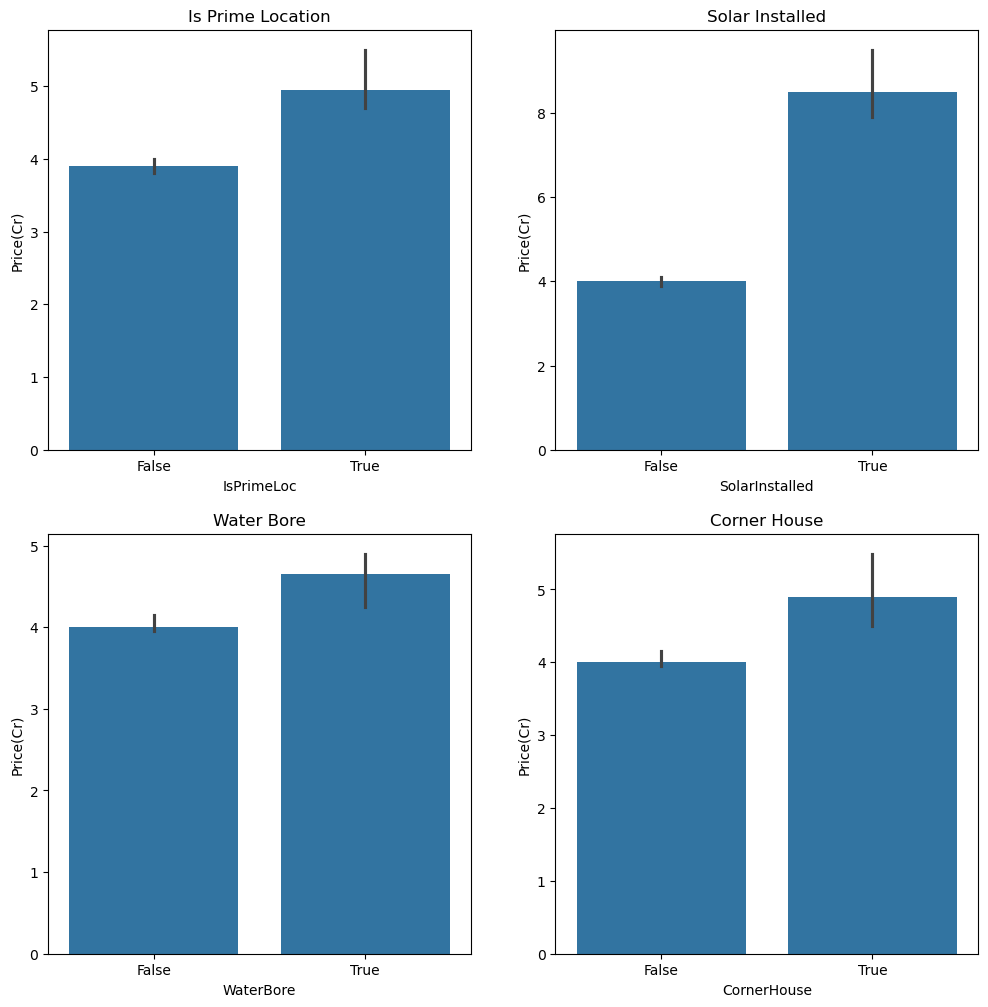

In [40]:
columns = ['IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse']

fig , axes = plt.subplots(2,2,figsize=(12,12))

sns.barplot(x=df['IsPrimeLoc'],y=df['Price(Cr)'],estimator=np.median,ax=axes[0][0])
axes[0][0].set_title('Is Prime Location')

sns.barplot(x=df['SolarInstalled'],y=df['Price(Cr)'],estimator=np.median,ax=axes[0][1])
axes[0][1].set_title('Solar Installed')

sns.barplot(x=df['WaterBore'],y=df['Price(Cr)'],estimator=np.median,ax=axes[1][0])
axes[1][0].set_title('Water Bore')

sns.barplot(x=df['CornerHouse'],y=df['Price(Cr)'],estimator=np.median,ax=axes[1][1])
axes[1][1].set_title('Corner House')

 - *Corner House, Prime Location, Solar Panels Installed influcence Price, while Water Boring doesn't*

## Luxury type

<Axes: xlabel='luxury_type', ylabel='Price(Cr)'>

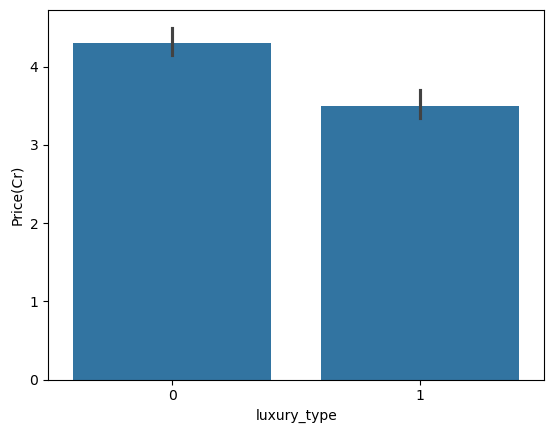

In [41]:
sns.barplot(x=df['luxury_type'],y=df['Price(Cr)'],estimator=np.median)

<Axes: xlabel='luxury_type', ylabel='Price(Cr)'>

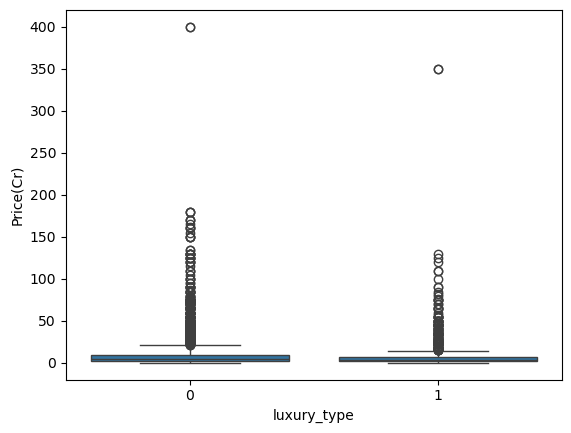

In [42]:
sns.boxplot(x=df['luxury_type'],y=df['Price(Cr)'])

### Observations 
- luxury type = 1 seems to have a greater Median of Price

## Built in Year

In [43]:
df[df['Built in year']<1900]['Built in year'].value_counts()

Built in year
1.0       393
2.0        32
10.0       11
5.0        10
3.0        10
4.0         8
8.0         4
7.0         4
6.0         4
20.0        2
0.0         2
12.0        2
15.0        2
40.0        1
205.0       1
21.0        1
1898.0      1
225.0       1
18.0        1
1887.0      1
25.0        1
28.0        1
1889.0      1
23.0        1
Name: count, dtype: int64

In [44]:
df.columns

Index(['Building', 'Main Location', 'Type', 'Price(Cr)', 'Bath(s)',
       'Area(Marla)', 'Bedroom(s)', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Floor in Building', 'Bedrooms',
       'Bathrooms', 'Servant Quarters', 'Kitchens', 'Store Rooms',
       'Swimming Pool', 'Sauna', 'Jacuzzi', 'Security Staff',
       'Maintenance Staff', 'Facilities for Disabled',
       'Laundry or Dry Cleaning Facility', 'Communal/Shared Kitchen',
       'Storey Unit'],
      dtype='str')

## 'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators'

<Axes: xlabel='Parking Spaces', ylabel='Price(Cr)'>

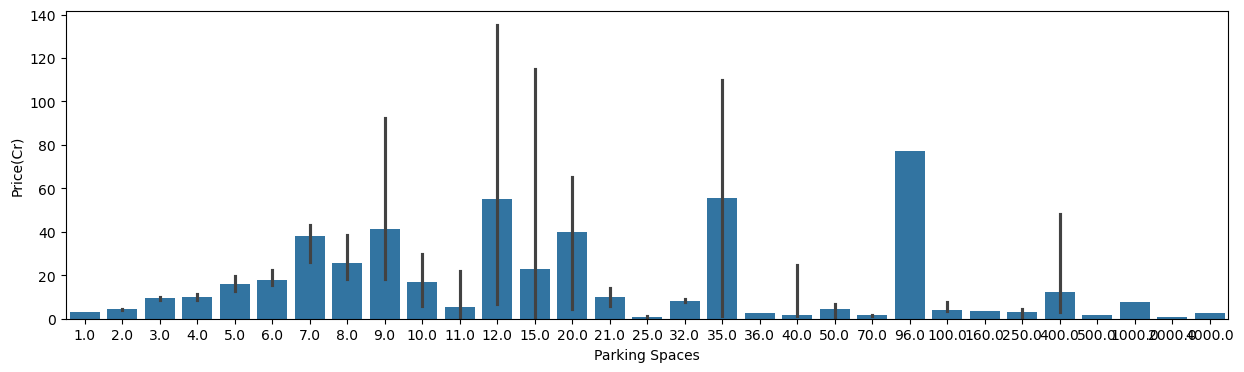

In [45]:
plt.figure(figsize=(15,4))
sns.barplot(x=df['Parking Spaces'],y=df['Price(Cr)'],estimator=np.median)

<Axes: xlabel='Floor', ylabel='Price(Cr)'>

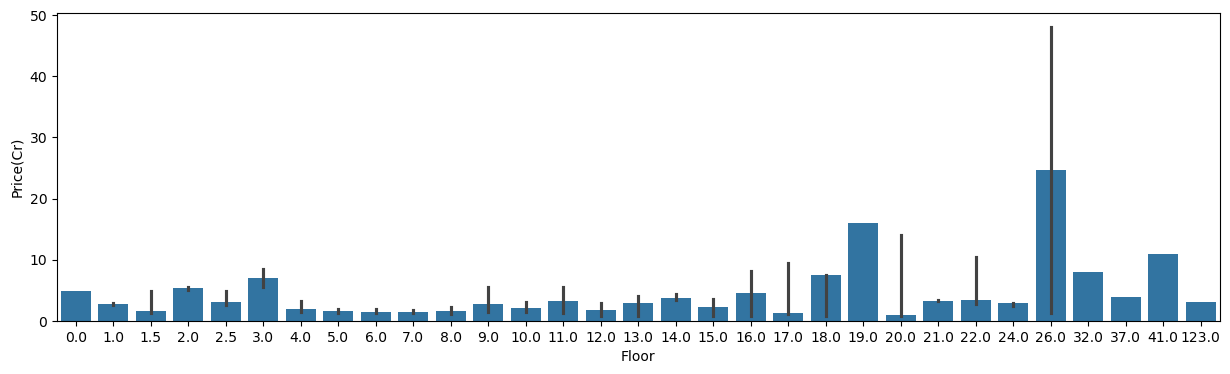

In [46]:
plt.figure(figsize=(15,4))
sns.barplot(x=df['Floor'],y=df['Price(Cr)'],estimator=np.median)

<Axes: xlabel='Elevators', ylabel='Price(Cr)'>

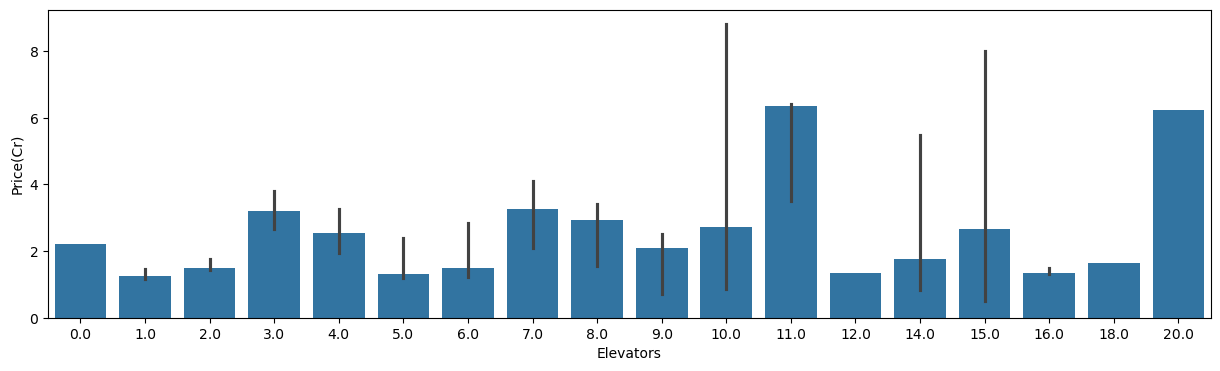

In [47]:
plt.figure(figsize=(15,4))
sns.barplot(x=df['Elevators'],y=df['Price(Cr)'],estimator=np.median)

## Servant Quarters

<Axes: xlabel='Servant Quarters', ylabel='Price(Cr)'>

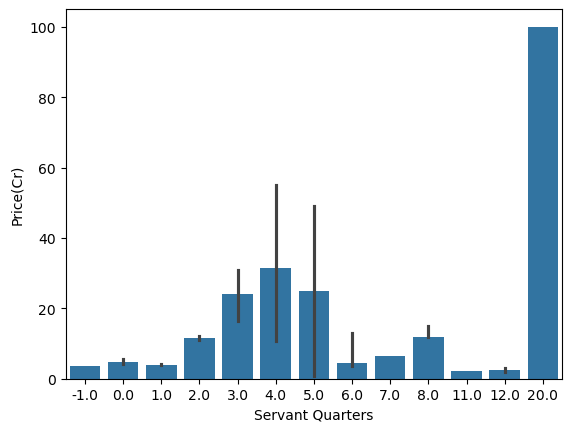

In [48]:
# plt.figure(figsize=(15,4))
sns.barplot(x=df['Servant Quarters'],y=df['Price(Cr)'],estimator=np.median)

## Kitchens

<Axes: xlabel='Kitchens', ylabel='Price(Cr)'>

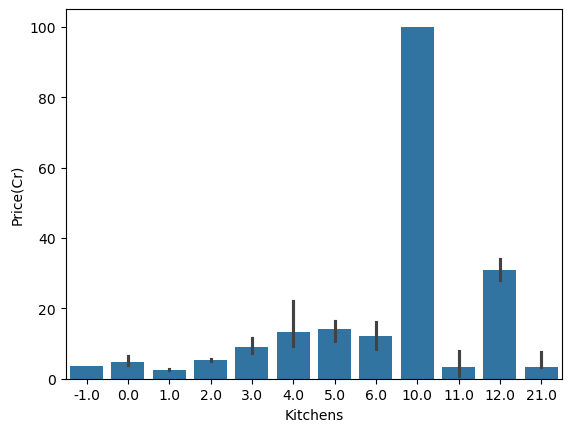

In [49]:
# plt.figure(figsize=(15,4))
sns.barplot(x=df['Kitchens'],y=df['Price(Cr)'],estimator=np.median)

<Axes: xlabel='Kitchens', ylabel='Price(Cr)'>

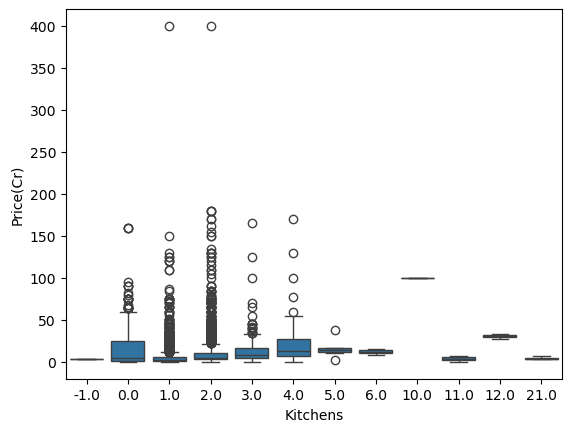

In [50]:
sns.boxplot(x=df['Kitchens'],y=df['Price(Cr)'])

## Store Rooms

<Axes: xlabel='Store Rooms', ylabel='Price(Cr)'>

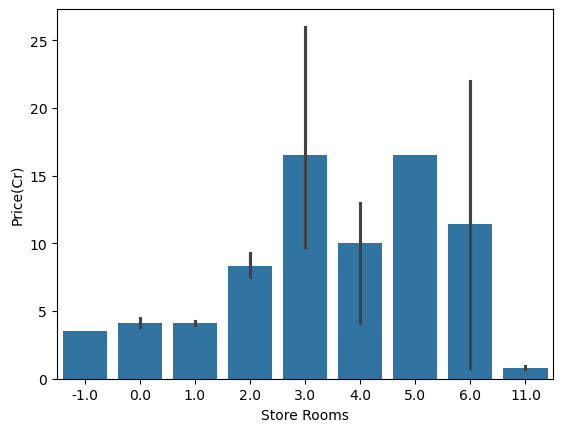

In [51]:
sns.barplot(x=df['Store Rooms'],y=df['Price(Cr)'],estimator=np.median)

## Storey Unit

<Axes: xlabel='Storey Unit', ylabel='Price(Cr)'>

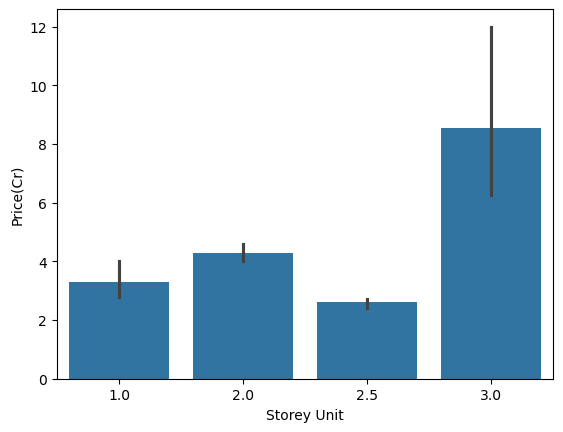

In [52]:
sns.barplot(x=df['Storey Unit'],y=df['Price(Cr)'],estimator=np.median)

### Observations
- Storey Unit = 3 tends to have a greater Price.

In [53]:
df.columns

Index(['Building', 'Main Location', 'Type', 'Price(Cr)', 'Bath(s)',
       'Area(Marla)', 'Bedroom(s)', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Floor in Building', 'Bedrooms',
       'Bathrooms', 'Servant Quarters', 'Kitchens', 'Store Rooms',
       'Swimming Pool', 'Sauna', 'Jacuzzi', 'Security Staff',
       'Maintenance Staff', 'Facilities for Disabled',
       'Laundry or Dry Cleaning Facility', 'Communal/Shared Kitchen',
       'Storey Unit'],
      dtype='str')

<Axes: xlabel='Swimming Pool', ylabel='Price(Cr)'>

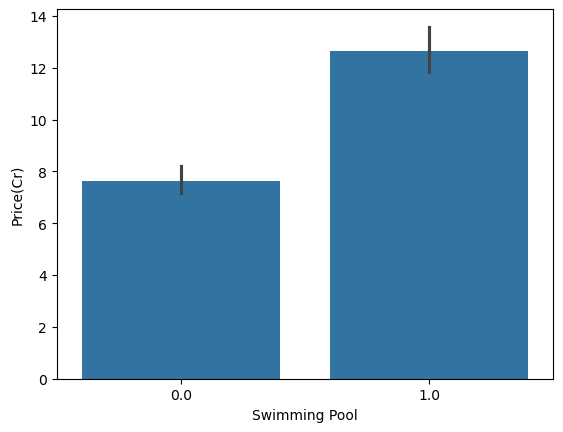

In [54]:
sns.barplot(data=df.fillna(0),x='Swimming Pool',y='Price(Cr)')

<Axes: xlabel='Communal/Shared Kitchen', ylabel='Price(Cr)'>

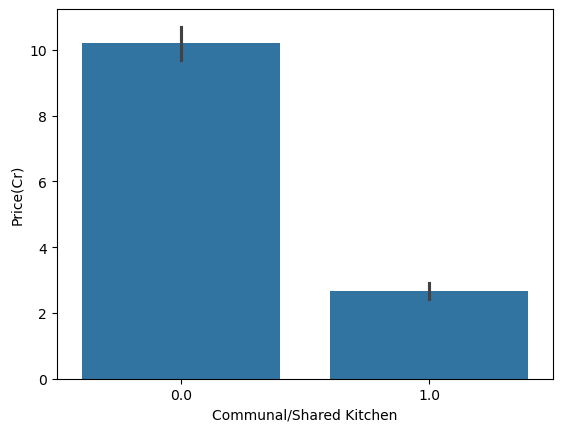

In [55]:
sns.barplot(data=df.fillna(0),x='Communal/Shared Kitchen',y='Price(Cr)')

## Change of Strategy
1. Removing Farm Houses (b/c our end goal is Price Predictor for Houses and Flats, inlcuding Farm Houses would have a negative effect on our Predictive Model)
2. Making a separate dataset for Flats since Flats have its own features which are not present in Houses
3. And merging Penthouse with Flats

In [58]:
df['Type'].value_counts()

Type
House         4521
Flat          1729
Farm House      89
Penthouse       14
Name: count, dtype: int64

In [59]:
df = df[df['Type']!= 'Farm House']

In [60]:
flats = df[df['Type']!='House']

In [61]:
flats.shape

(1743, 38)

In [62]:
houses = df[df['Type']=='House']

In [63]:
houses.shape

(4521, 38)

In [64]:
# Saving files

flats.to_csv('flats.csv')
houses.to_csv('houses.csv')